#### Name: Sutton Ursillo

# PHYS 230 Lab Assignment 16

### Monday, April 6, 2026: Chapter 8.6
- Boundary Value Problems

*Don't forget to put a markdown cell at the end of each problem explaining your process and results AND comments in all cells*

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The Shooting Method

Find a solution to the boundary value problem: 
$$\frac{d^2y}{dt^2} = -y$$
where $y$ is the position of an object, and $y(t=0) = 1$ and $y(t=1) = 2$. To do this, complete the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. (Convert the cell below to markdown first)

$\frac{dy}{dt} = v$

$\frac{dv}{dt} = -y$

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1 using a vector `r` that containts two elements. 

In [ ]:
#defining the func

def f(r,t): 
    y = r[0]
    v = r[1]

    fy = v
    fv = -y

    return np.array([fy,fv], float)

#### Step 3: Define any constants, boundary conditions, and arrays necessary for the problem and solve for the initial velocity $\left(\frac{dy}{dt}\right)$. 

In [ ]:
#constants

g = 9.81 #m/s^2 
t1 = 0.0
t2 = 1.0
y0 = 1.0
y_target = 2.0
N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2,h)
target = 1e-10


#### Step 4: Use fourth-order Runge-Kutta combined with the binary search method to find the initial velocity ($\frac{dy}{dt}$) that solves the boundary value problem. Note: in this case the final point is not 0. In order to use binary search, you will need to subtract the final height from the runge-kutta found height using your initial guess to see if it is zero or not. 

In [ ]:
def height(v,tpts,h):
    #tpts is an array of time values spaced by h
    #v is the inital velo guess

    r = np.array([y0,v], float)

    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1,t+0.5*h)
        k3 = h*f(r+0.5*k2,t+0.5*h)
        k4 = h*f(r+k3,t+h)

        r += (k1+2*k2+2*k3+k4)/6

    return r[0]


#set initial values

v1 = 0.01
v2 = 900
h1 = height(v1,tpts,h) - y_target
h2 = height(v2,tpts,h) - y_target
print(h1,h2)


#binary search method

while abs(h2-h1)> target:
    vp = (v1+v2)/2
    hp = height(vp,tpts, h) - y_target
    if h1*hp > 0:
        v1 = vp
        h1 = hp
    else:
        v2 = vp
        h2 = hp

vf = (v1+v2)/2


print("the required initial velocity is", round(vf,6), "m/s")

-1.4512829842837753 755.8641886329715
the required initial velocity is 1.734698 m/s


#### Step 5: Analyze the accuracy of your result. One way you could do this is to plug your two now initial conditions back into fourth-order runge-kutta to solve for all $y$ values and make a plot of $y$ vs. $t$. In a markdown cell, briefly comment on the results. 

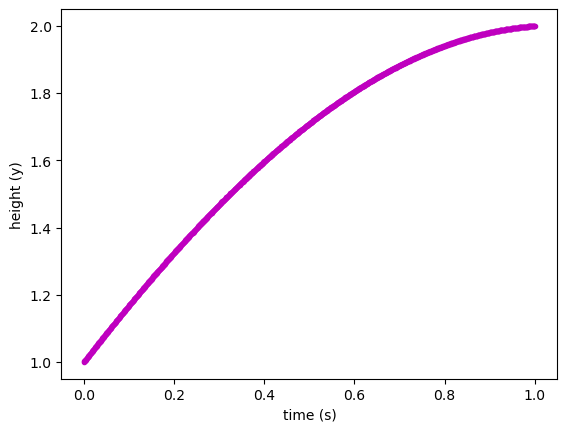

1.999999999959882


In [49]:

#apply 4th order RK


# define rnage of values

t1 = 0.0
t2 = 1.0
N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2+h,h)
xpts = np.zeros(len(tpts))
ypts = np.zeros(len(tpts))

target = 1e-10

#tpts is an array of time values spaced by h
#v is the inital velo guess
r = np.array([y0,vf], float)

for i in range(len(tpts)):
    xpts[i] = r[0]
    ypts[i] = r[1]
    k1 = h*f(r,tpts[i])
    k2 = h*f(r+0.5*k1,tpts[i]+0.5*h)
    k3 = h*f(r+0.5*k2,tpts[i]+0.5*h)
    k4 = h*f(r+k3,tpts[i]+h)
    r += (k1+2*k2+2*k3+k4)/6


plt.plot(tpts, xpts, ".m")
plt.xlabel("time (s)")
plt.ylabel("height (y)")
plt.show()

print(xpts[-1])


From the graph we can see that with the initial velocity the projectile approaches the boundary that was set in the time frame that was set. Printing the final posistion of the object also shows that it is within the target error. 

### Eigenvalue Problems 

Find the smallest positive eigenvalue $z$ for the equation:
	    $$\frac{d^2y}{dt^2} = -z y$$
	    where $y(t =-1) = 0$ and $y(t = 1) = 0$. Try searching in the range $0.0 \leq z \leq 10.0$. To do this, complete the following steps:

#### Step 1: define the function `f(r,t,z)` that applies values (including your initial guess of $z$ and a vector `r` that containts two elements) to the two first-order differential equations needed for this problem. You may find it beneficial to write our your two first-order differential equations first. 

writing down the differential equations

$\frac{dy}{dt} = v$

$\frac{dv}{dt} = -zy$

In [61]:
def f(r,t,z):
    y = r[0]
    v = r[1]

    fy = v
    fv = -z*y

    return np.array([fy,fv], float)

#### Step 2: Define any constants, time constraints, and initial/boundary values necessay to apply fourth-order runge-kutta and either the binary search or secant method to solve this problem

In [65]:
g = 9.81 #m/s^2 
t1 = -1.0
t2 = 1.0
N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2,h)
target = 1e-10

#### Step 3: Solve for $z$ using fourth-order runge-kutta and the root method of your choice (binary, secant)

In [ ]:
def RK4(z):
    r = np.array([0.0,1.0], float) #initial guess
    xpts = np.arange(t1,t2,h)

    for x in xpts:
        k1 = h*f(r,x,z)
        k2 = h*f(r+0.5*k1,x+0.5*h,z)
        k3 = h*f(r+0.5*k2,x+0.5*h,z)
        k4 = h*f(r+k3,x+h,z)
        r += (k1+2*k2+2*k3+k4)/6

    return r[0]

#secant method

Z1 = 1.0
Z2 = 3.0

y1 = RK4(Z1)
y2 = RK4(Z2)
        
while abs(Z2-Z1) > target:
    y1,y2 = y2, RK4(Z2)
    Z1,Z2 = Z2, Z2 - y2*(Z2-Z1)/(y2-y1)


print("z=", Z2)
print("y(1) =", RK4(Z2))
#this is as far as I got
#I couldn't figure out why I was getting nans 

z= nan
y(1) = nan


/var/folders/d6/b8g7b2494mddckgpchslt48r0000gn/T/ipykernel_48172/3344907379.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  Z1,Z2 = Z2, Z2 - y2*(Z2-Z1)/(y2-y1)
/var/folders/d6/b8g7b2494mddckgpchslt48r0000gn/T/ipykernel_48172/1919485248.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  fv = -z*y


This is as far as I got.

#### Step 4: Does your value of $z$ make sense? Show below by plugging initial conditions back into fourth-order Runge-Kutta and plotting $y$ vs. $t$. What happens if you change the initial guess of $v = \frac{dy}{dt}$? 